In [4]:
# importação das bibliotecas principais
import torch
import torch.nn as nn
from torch.optim import SGD
import matplotlib.pyplot as plt

# comando específico para exibir graficos
%matplotlib inline

In [5]:
# definição do dataset
x = [[1,2], [3,4], [5,6], [7,8]]
y = [[3], [7], [11], [15]]

In [6]:
# conversão das listas para tensores do pytorch
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [7]:
# configuração do dispositivo de hardware
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
# transferencia dos tensores
X = X.to(device)
Y = Y.to(device)

In [10]:
# definição da arquitetura da rede neural
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)

    # define o caminho que o dado percorre pelas camadas
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

In [15]:
# instancia o modelo para criar o objeto da rede neural
model = MyNeuralNet()

In [16]:
# recebe os parametros do modelo e define a taxa de aprendizado
opt = SGD(model.parameters(), lr=0.001)

In [20]:
# lista para armazenar o histórico de erro e loop de 50 de treinamento
losses = []
loss_fn = nn.MSELoss()
for _ in range(50):
    opt.zero_grad()
    loss_value = loss_fn(model(X), Y)
    loss_value.backward()
    opt.step()
    # Salva a perda para plotar depois
    losses.append(loss_value.detach().numpy())

Text(0, 0.5, 'Valor do Erro')

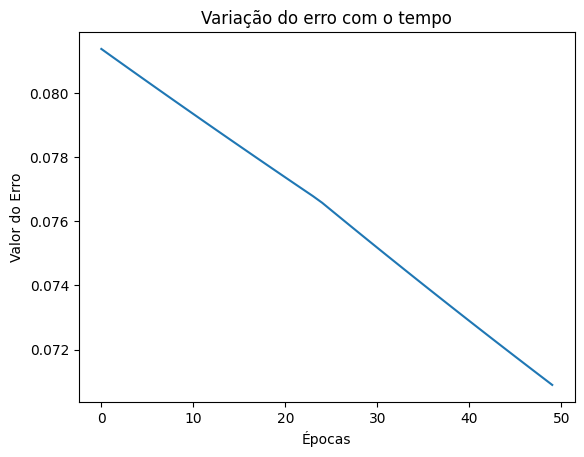

In [21]:
plt.plot(losses)
plt.title("Variação do erro com o tempo")
plt.xlabel("Épocas")
plt.ylabel("Valor do Erro")